# Core Benchmark Analysis

Notebook ini digunakan untuk mempresentasikan dan menganalisis hasil benchmark inti yang dihasilkan oleh pipeline `experiments/scripts/run_core_checkpoint.py`.

Notebook ini berfungsi untuk:
- Memverifikasi bahwa artefak yang dibaca sesuai dengan run yang dimaksud,
- Menyajikan hasil dalam bentuk tabel dan visualisasi yang lebih mudah ditafsirkan,
- Mendokumentasikan interpretasi teknikal terhadap performa masing-masing engine.

## Content

Alur analisis pada notebook ini disusun agar konsisten dengan logika evaluasi eksperimental, pengelompokan skenario, dan hierarki metrik. Pembacaan hasil dibagi menjadi:

1. Provenance dan desain eksperimen,
2. Klasifikasi skenario,
3. Outcome utama pada skenario operasional,
4. Validasi constraint pada skenario operasional,
5. Stress test dan kontrol infeasible,
6. Analisis stabilitas,
7. Matriks keputusan dan efisiensi.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("default")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)

ENGINE_ORDER = ["dice", "ocean", "ft", "nn"]
SCENARIO_ORDER = ["all_mutable", "lifestyle_combo", "minimal_realistic_combo", "bmi_only", "activity_only", "tight_bounds", "no_mutable"]
ENGINE_COLORS = {"dice": "#1f77b4", "ocean": "#ff7f0e", "ft": "#2ca02c", "nn": "#d62728"}

SCENARIO_GROUPS = {
    "operational": ["all_mutable", "lifestyle_combo", "minimal_realistic_combo", "bmi_only"],
    "stress_test": ["activity_only", "tight_bounds"],
    "infeasible_control": ["no_mutable"],
}
SCENARIO_GROUP_LABELS = {
    "operational": "Operational",
    "stress_test": "Stress Test",
    "infeasible_control": "Infeasible Control",
}

SCENARIO_NUMERIC_COLS = [
    "total_cases",
    "feasible_cases",
    "feasible_rate",
    "mean_runtime_ms",
    "mean_candidate_count",
    "candidate_rows",
    "requests_with_candidates",
    "target_success_rate",
    "plausibility_pass_rate",
    "immutable_violation_rate",
    "mutable_violation_rate",
    "bounds_violation_rate",
    "directional_violation_rate",
    "mean_lof_score",
    "mean_distance_l1",
    "mean_changed_feature_count",
    "target_success_rate_all_candidates",
    "plausibility_pass_rate_all_candidates",
    "immutable_violation_rate_all_candidates",
    "mutable_violation_rate_all_candidates",
    "bounds_violation_rate_all_candidates",
    "directional_violation_rate_all_candidates",
    "mean_lof_score_all_candidates",
    "mean_distance_l1_all_candidates",
    "mean_changed_feature_count_all_candidates",
    "step_runtime_seconds",
]

STABILITY_NUMERIC_COLS = [
    "case_count",
    "mean_feasible_rate",
    "fully_feasible_case_count",
    "fully_feasible_case_rate",
    "stability_evaluable_case_count",
    "stability_evaluable_case_rate",
    "mean_jaccard_changed_features",
    "mean_stability_std_norm",
    "mean_feasible_only_jaccard_changed_features",
    "mean_feasible_only_stability_std_norm",
]


def style_metric_table(
    frame: pd.DataFrame,
    percent_cols: list[str] | None = None,
    precision: int = 3,
    hide_index: bool = False,
):
    percent_cols = percent_cols or []
    formatters = {col: lambda x: f"{x:.1%}" if pd.notna(x) else "-" for col in percent_cols if col in frame.columns}
    for col in frame.columns:
        if col in formatters:
            continue
        if pd.api.types.is_float_dtype(frame[col]):
            formatters[col] = lambda x, p=precision: f"{x:.{p}f}" if pd.notna(x) else "-"
    styled = frame.style.format(formatters)
    if hide_index:
        styled = styled.hide(axis="index")
    return styled


def extract_engine_from_source(path_like: str) -> str:
    lower = str(path_like).lower()
    for engine in ENGINE_ORDER:
        needle = f"\\{engine}\\"
        if needle in lower:
            return engine
    return "unknown"


def classify_scenario(name: str) -> str:
    for group_name, names in SCENARIO_GROUPS.items():
        if name in names:
            return group_name
    return "unknown"

In [2]:
def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Repo root not found from notebook path.")


REPO_ROOT = find_repo_root(Path.cwd())
RESULTS_ROOT = REPO_ROOT / "experiments" / "results"
LATEST_COMPARISON_POINTER = RESULTS_ROOT / "latest" / "comparison.txt"

if not LATEST_COMPARISON_POINTER.exists():
    raise FileNotFoundError(f"Latest comparison pointer not found: {LATEST_COMPARISON_POINTER}")

COMPARISON_ROOT = Path(LATEST_COMPARISON_POINTER.read_text(encoding="utf-8").strip())
CHECKPOINT_REPORT_PATH = COMPARISON_ROOT / "checkpoint_report.md"
COMPARISON_REPORT_PATH = COMPARISON_ROOT / "comparison_report.md"
CHECKPOINT_MANIFEST_PATH = COMPARISON_ROOT / "checkpoint_manifest.json"
COMPARISON_MANIFEST_PATH = COMPARISON_ROOT / "comparison_manifest.json"
AUDIT_REPORT_PATH = COMPARISON_ROOT / "audit_report.json"
COMBINED_DIR = COMPARISON_ROOT / "combined"

SCENARIO_SUMMARY_PATH = COMBINED_DIR / "scenario_summary.csv"
STABILITY_SUMMARY_PATH = COMBINED_DIR / "stability_summary.csv"
CANDIDATES_PATH = COMBINED_DIR / "candidates.csv"
INPUTS_PATH = COMBINED_DIR / "inputs.csv"

comparison_manifest = json.loads(COMPARISON_MANIFEST_PATH.read_text(encoding="utf-8"))
checkpoint_manifest = json.loads(CHECKPOINT_MANIFEST_PATH.read_text(encoding="utf-8"))
audit_report = json.loads(AUDIT_REPORT_PATH.read_text(encoding="utf-8"))

scenario_df = pd.read_csv(SCENARIO_SUMMARY_PATH) if SCENARIO_SUMMARY_PATH.exists() else pd.DataFrame()
stability_df = pd.read_csv(STABILITY_SUMMARY_PATH) if STABILITY_SUMMARY_PATH.exists() else pd.DataFrame()
candidates_df = pd.read_csv(CANDIDATES_PATH) if CANDIDATES_PATH.exists() else pd.DataFrame()
inputs_df = pd.read_csv(INPUTS_PATH) if INPUTS_PATH.exists() else pd.DataFrame()

for col in SCENARIO_NUMERIC_COLS:
    if col in scenario_df.columns:
        scenario_df[col] = pd.to_numeric(scenario_df[col], errors="coerce")

for col in STABILITY_NUMERIC_COLS:
    if col in stability_df.columns:
        stability_df[col] = pd.to_numeric(stability_df[col], errors="coerce")

print(f"Comparison root: {COMPARISON_ROOT}")
print(f"Scenario rows: {len(scenario_df)} | Stability rows: {len(stability_df)}")
print(f"Candidate rows: {len(candidates_df)} | Input rows: {len(inputs_df)}")

Comparison root: D:\Perkuliahan\Tugas Akhir - The Last Chapter\Program\diabetify-cf\experiments\results\comparisons\20260509_050703
Scenario rows: 28 | Stability rows: 4
Candidate rows: 382 | Input rows: 560


## 1. Provenance and Experimental Design

Bagian ini memastikan bahwa notebook membaca artefak hasil yang benar dan bahwa konfigurasi eksperimen yang divisualisasikan memang sesuai dengan benchmark inti yang direncanakan.

In [3]:
design_summary = pd.DataFrame(
    [
        {
            "engines": ", ".join(comparison_manifest.get("engines", [])),
            "scenario_count": len(comparison_manifest.get("scenario_configs", [])),
            "scenario_limit": comparison_manifest.get("scenario_limit"),
            "stability_limit": comparison_manifest.get("stability_limit"),
            "repeat_count": comparison_manifest.get("repeat_count"),
            "scenario_timeout_seconds": comparison_manifest.get("scenario_timeout_seconds"),
            "stability_timeout_seconds": comparison_manifest.get("stability_timeout_seconds"),
            "checkpoint_ok": checkpoint_manifest.get("ok"),
            "fail_on_timeout": audit_report.get("fail_on_timeout"),
        }
    ]
)
display(design_summary.T.rename(columns={0: "value"}))

,value
engines,"dice, ocean, ft, nn"
scenario_count,7
scenario_limit,20
stability_limit,10
repeat_count,5
scenario_timeout_seconds,180
stability_timeout_seconds,180
checkpoint_ok,True
fail_on_timeout,True


## 2. Klasifikasi Skenario

Skenario tidak dibaca sebagai kumpulan variasi yang setara. Dalam notebook ini, skenario dipisahkan menjadi tiga kelompok: `operational`, `stress_test`, dan `infeasible_control`. Pemisahan ini penting agar `feasible_rate` utama tidak tercampur dengan skenario yang memang dirancang untuk mempersempit atau menutup ruang solusi.

Tabel di bawah ini berfungsi sebagai peta pembacaan. Seluruh hasil setelahnya selalu harus diinterpretasikan sesuai kelompok skenario masing-masing.

In [4]:
scenario_catalog = pd.DataFrame([
    {
        "scenario": name,
        "group": group_name,
        "group_label": SCENARIO_GROUP_LABELS.get(group_name, group_name),
    }
    for group_name, names in SCENARIO_GROUPS.items()
    for name in names
]).sort_values(["group", "scenario"]).reset_index(drop=True)

display(scenario_catalog.style.hide(axis="index"))

scenario,group,group_label
no_mutable,infeasible_control,Infeasible Control
all_mutable,operational,Operational
bmi_only,operational,Operational
lifestyle_combo,operational,Operational
minimal_realistic_combo,operational,Operational
activity_only,stress_test,Stress Test
tight_bounds,stress_test,Stress Test


## 3. Outcome Utama pada Skenario Operasional

Bagian ini adalah headline utama benchmark. Hanya skenario operasional yang dibaca di sini, karena kelompok inilah yang paling dekat dengan konteks penggunaan nyata dan memang diharapkan masih memiliki ruang solusi.

Metrik yang diperlakukan sebagai outcome utama pada bagian ini adalah `feasible_rate` dan `plausibility_pass_rate`. `mean_lof_score` tetap ditampilkan, tetapi dibaca sebagai metrik pendukung plausibility, bukan metrik utama ranking tersendiri. Runtime tidak ditampilkan di sini agar pembacaan efisiensi tetap terpusat pada section keputusan dan efisiensi di bagian akhir.

engine,scenario,feasible_rate,plausibility_pass_rate,mean_lof_score
dice,all_mutable,100.0%,100.0%,1.311
ocean,all_mutable,60.0%,100.0%,1.009
ft,all_mutable,40.0%,100.0%,1.006
nn,all_mutable,100.0%,100.0%,1.016
dice,lifestyle_combo,100.0%,100.0%,1.070
ocean,lifestyle_combo,60.0%,100.0%,1.013
ft,lifestyle_combo,40.0%,100.0%,1.006
nn,lifestyle_combo,100.0%,100.0%,1.017
dice,minimal_realistic_combo,70.0%,100.0%,1.322
ocean,minimal_realistic_combo,20.0%,100.0%,1.010


C:\Users\ASUS\AppData\Local\Temp\ipykernel_25836\3504149778.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  operational_outcome_view.groupby("engine", as_index=False)


engine,feasible_rate,plausibility_pass_rate,mean_lof_score
dice,85.0%,100.0%,1.185
ocean,40.0%,100.0%,1.011
ft,37.5%,75.0%,0.757
nn,81.2%,100.0%,1.019


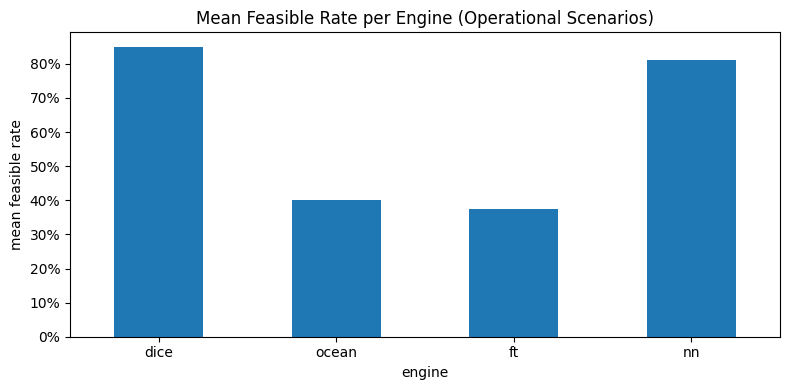

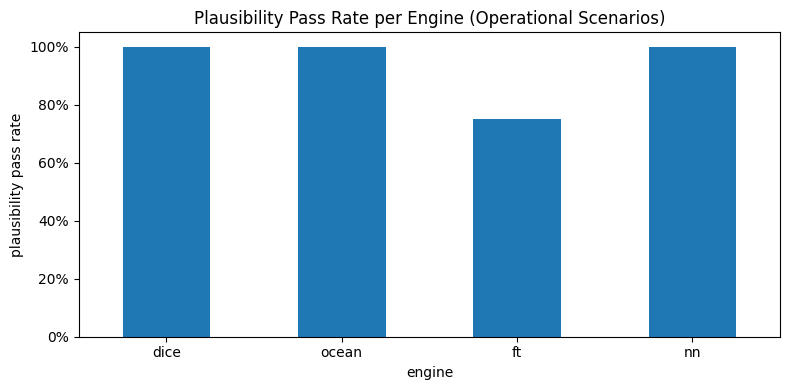

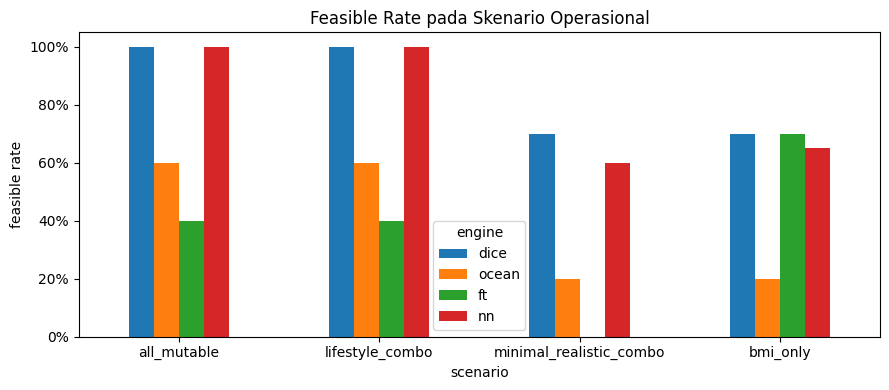

In [5]:
scenario_view = scenario_df.copy()
if not scenario_view.empty:
    scenario_view["engine"] = pd.Categorical(
        scenario_view["source_file"].map(extract_engine_from_source),
        categories=ENGINE_ORDER,
        ordered=True,
    )
    scenario_view["scenario_group"] = scenario_view["scenario"].map(classify_scenario)
    scenario_view["scenario_group_label"] = scenario_view["scenario_group"].map(lambda x: SCENARIO_GROUP_LABELS.get(x, x))
    scenario_view["scenario"] = pd.Categorical(scenario_view["scenario"], categories=SCENARIO_ORDER, ordered=True)

    operational_outcome_view = scenario_view.loc[
        scenario_view["scenario_group"] == "operational",
        [
            "engine",
            "scenario",
            "feasible_rate",
            "plausibility_pass_rate",
            "mean_lof_score",
        ],
    ].sort_values(["scenario", "engine"]).reset_index(drop=True)

    display(
        style_metric_table(
            operational_outcome_view,
            percent_cols=["feasible_rate", "plausibility_pass_rate"],
            hide_index=True,
        )
    )

    operational_engine_summary = (
        operational_outcome_view.groupby("engine", as_index=False)
        .agg(
            feasible_rate=("feasible_rate", "mean"),
            plausibility_pass_rate=("plausibility_pass_rate", "mean"),
            mean_lof_score=("mean_lof_score", "mean"),
        )
        .sort_values("engine")
        .reset_index(drop=True)
    )

    display(
        style_metric_table(
            operational_engine_summary,
            percent_cols=["feasible_rate", "plausibility_pass_rate"],
            hide_index=True,
        )
    )


    engine_feasible_plot = operational_engine_summary.set_index("engine")[["feasible_rate"]].reindex(ENGINE_ORDER)
    ax = engine_feasible_plot.plot(
        kind="bar",
        figsize=(8, 4),
        rot=0,
        legend=False,
        color=[ENGINE_COLORS.get(engine, "#4b5563") for engine in engine_feasible_plot.index],
    )
    ax.set_title("Mean Feasible Rate per Engine (Operational Scenarios)")
    ax.set_xlabel("engine")
    ax.set_ylabel("mean feasible rate")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    plt.tight_layout()
    plt.show()

    engine_plausibility_plot = operational_engine_summary.set_index("engine")[["plausibility_pass_rate"]].reindex(ENGINE_ORDER)
    ax = engine_plausibility_plot.plot(
        kind="bar",
        figsize=(8, 4),
        rot=0,
        legend=False,
        color=[ENGINE_COLORS.get(engine, "#4b5563") for engine in engine_plausibility_plot.index],
    )
    ax.set_title("Plausibility Pass Rate per Engine (Operational Scenarios)")
    ax.set_xlabel("engine")
    ax.set_ylabel("plausibility pass rate")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    plt.tight_layout()
    plt.show()
    operational_pivot = operational_outcome_view.pivot(index="scenario", columns="engine", values="feasible_rate").reindex(index=SCENARIO_GROUPS["operational"], columns=ENGINE_ORDER)
    ax = operational_pivot.plot(
        kind="bar",
        figsize=(9, 4),
        rot=0,
        color=[ENGINE_COLORS.get(engine, "#4b5563") for engine in operational_pivot.columns],
    )
    ax.set_title("Feasible Rate pada Skenario Operasional")
    ax.set_ylabel("feasible rate")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    plt.tight_layout()
    plt.show()

    best_operational = operational_engine_summary.sort_values(["feasible_rate", "plausibility_pass_rate"], ascending=[False, False]).iloc[0]


## 4. Validasi Constraint pada Skenario Operasional

Bagian ini bukan dipakai untuk menentukan pemenang utama, tetapi untuk memastikan bahwa engine yang dibandingkan tidak melanggar syarat dasar penelitian. Violation rate yang semuanya nol tetap penting, karena itu berarti benchmark dijalankan di atas solusi yang sama-sama patuh terhadap constraint inti.

Dengan kata lain, section ini dibaca sebagai **constraint gate**, bukan sebagai papan skor utama.

In [6]:
if not scenario_df.empty:
    constraint_view = scenario_view.loc[
        scenario_view["scenario_group"] == "operational",
        [
            "engine",
            "scenario",
            "immutable_violation_rate",
            "mutable_violation_rate",
            "bounds_violation_rate",
            "directional_violation_rate",
        ],
    ].sort_values(["scenario", "engine"]).reset_index(drop=True)

    display(
        style_metric_table(
            constraint_view,
            percent_cols=[
                "immutable_violation_rate",
                "mutable_violation_rate",
                "bounds_violation_rate",
                "directional_violation_rate",
            ],
            hide_index=True,
        )
    )

    constraint_summary = (
        constraint_view.groupby("engine", as_index=False)
        .agg(
            immutable_violation_rate=("immutable_violation_rate", "mean"),
            mutable_violation_rate=("mutable_violation_rate", "mean"),
            bounds_violation_rate=("bounds_violation_rate", "mean"),
            directional_violation_rate=("directional_violation_rate", "mean"),
        )
        .sort_values("engine")
        .reset_index(drop=True)
    )

    display(
        style_metric_table(
            constraint_summary,
            percent_cols=[
                "immutable_violation_rate",
                "mutable_violation_rate",
                "bounds_violation_rate",
                "directional_violation_rate",
            ],
            hide_index=True,
        )
    )

    all_zero = bool((constraint_summary[[
        "immutable_violation_rate",
        "mutable_violation_rate",
        "bounds_violation_rate",
        "directional_violation_rate",
    ]] == 0).all().all())

engine,scenario,immutable_violation_rate,mutable_violation_rate,bounds_violation_rate,directional_violation_rate
dice,all_mutable,0.0%,0.0%,0.0%,0.0%
ocean,all_mutable,0.0%,0.0%,0.0%,0.0%
ft,all_mutable,0.0%,0.0%,0.0%,0.0%
nn,all_mutable,0.0%,0.0%,0.0%,0.0%
dice,lifestyle_combo,0.0%,0.0%,0.0%,0.0%
ocean,lifestyle_combo,0.0%,0.0%,0.0%,0.0%
ft,lifestyle_combo,0.0%,0.0%,0.0%,0.0%
nn,lifestyle_combo,0.0%,0.0%,0.0%,0.0%
dice,minimal_realistic_combo,0.0%,0.0%,0.0%,0.0%
ocean,minimal_realistic_combo,0.0%,0.0%,0.0%,0.0%


C:\Users\ASUS\AppData\Local\Temp\ipykernel_25836\2885102385.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  constraint_view.groupby("engine", as_index=False)


engine,immutable_violation_rate,mutable_violation_rate,bounds_violation_rate,directional_violation_rate
dice,0.0%,0.0%,0.0%,0.0%
ocean,0.0%,0.0%,0.0%,0.0%
ft,0.0%,0.0%,0.0%,0.0%
nn,0.0%,0.0%,0.0%,0.0%


## 5. Stress Test dan Kontrol Infeasible

Bagian ini tidak dipakai untuk outcome operasional utama. Tujuannya adalah membaca robustness metode saat ruang solusi dipersempit dan memverifikasi apakah engine menolak dengan benar ketika ruang aksi ditutup total.

`reason_counts` pada bagian ini dibaca sebagai metrik diagnostik. Jadi, section ini membantu menjawab **mengapa** request gagal, bukan siapa yang menang pada benchmark operasional utama.

In [7]:
if not scenario_df.empty:
    stress_view = scenario_view.loc[
        scenario_view["scenario_group"].isin(["stress_test", "infeasible_control"]),
        [
            "engine",
            "scenario_group_label",
            "scenario",
            "feasible_rate",
            "mean_runtime_ms",
            "reason_counts",
        ],
    ].sort_values(["scenario_group_label", "scenario", "engine"]).reset_index(drop=True)

    display(style_metric_table(stress_view, percent_cols=["feasible_rate"], hide_index=True))

    stress_summary = (
        stress_view.groupby(["engine", "scenario_group_label"], as_index=False)
        .agg(
            feasible_rate=("feasible_rate", "mean"),
            mean_runtime_ms=("mean_runtime_ms", "mean"),
        )
        .sort_values(["scenario_group_label", "engine"])
        .reset_index(drop=True)
    )
    display(style_metric_table(stress_summary, percent_cols=["feasible_rate"], hide_index=True))

engine,scenario_group_label,scenario,feasible_rate,mean_runtime_ms,reason_counts
dice,Infeasible Control,no_mutable,0.0%,4.050,"{""NO_MUTABLE_FEATURE"": 20}"
ocean,Infeasible Control,no_mutable,0.0%,3.700,"{""NO_MUTABLE_FEATURE"": 20}"
ft,Infeasible Control,no_mutable,0.0%,4.000,"{""NO_MUTABLE_FEATURE"": 20}"
nn,Infeasible Control,no_mutable,0.0%,4.050,"{""NO_MUTABLE_FEATURE"": 20}"
dice,Stress Test,activity_only,0.0%,98.700,"{""TARGET_UNREACHABLE_UNDER_CONSTRAINTS"": 20}"
ocean,Stress Test,activity_only,0.0%,2508.900,"{""TARGET_UNREACHABLE_UNDER_CONSTRAINTS"": 20}"
ft,Stress Test,activity_only,0.0%,27.150,"{""TARGET_UNREACHABLE_UNDER_CONSTRAINTS"": 20}"
nn,Stress Test,activity_only,0.0%,46.600,"{""MEDICAL_RULE_VIOLATION_ONLY"": 11, ""TARGET_UNREACHABLE_UNDER_CONSTRAINTS"": 9}"
dice,Stress Test,tight_bounds,0.0%,101.750,"{""TARGET_UNREACHABLE_UNDER_CONSTRAINTS"": 20}"
ocean,Stress Test,tight_bounds,0.0%,3080.950,"{""TARGET_UNREACHABLE_UNDER_CONSTRAINTS"": 20}"


C:\Users\ASUS\AppData\Local\Temp\ipykernel_25836\3958745188.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stress_view.groupby(["engine", "scenario_group_label"], as_index=False)


engine,scenario_group_label,feasible_rate,mean_runtime_ms
dice,Infeasible Control,0.0%,4.050
ocean,Infeasible Control,0.0%,3.700
ft,Infeasible Control,0.0%,4.000
nn,Infeasible Control,0.0%,4.050
dice,Stress Test,0.0%,100.225
ocean,Stress Test,0.0%,2794.925
ft,Stress Test,0.0%,100.600
nn,Stress Test,0.0%,42.525


## 6. Analisis Stabilitas

Analisis stabilitas mengevaluasi apakah engine menghasilkan rekomendasi yang konsisten ketika request yang sama dijalankan berulang kali. Pada bagian ini, stabilitas dibaca dalam tiga lapisan: konsistensi keberhasilan (`mean_feasible_rate`), konsistensi keberhasilan penuh (`fully_feasible_case_rate`), dan konsistensi struktur/besar perubahan pada run yang feasible.

Section ini adalah pelengkap penting bagi outcome operasional. Engine yang sering feasible tetapi tidak stabil tetap harus dibaca hati-hati.

engine,mean_feasible_rate,fully_feasible_case_rate,mean_feasible_only_jaccard_changed_features,mean_feasible_only_stability_std_norm
dice,100.0%,100.0%,72.1%,0.162
ocean,66.0%,60.0%,100.0%,0.000
ft,40.0%,40.0%,100.0%,0.000
nn,100.0%,100.0%,100.0%,0.000


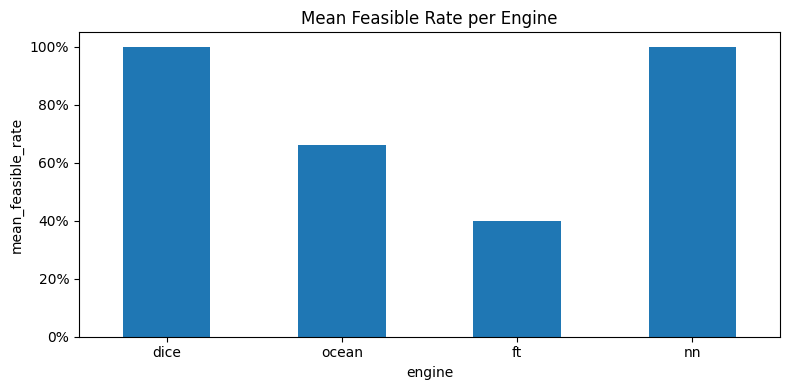

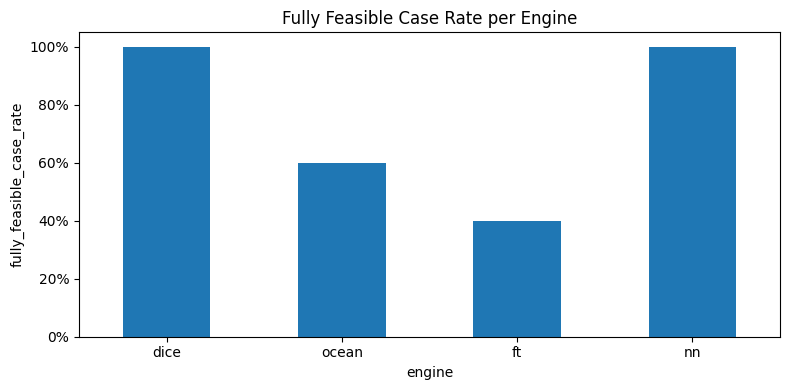

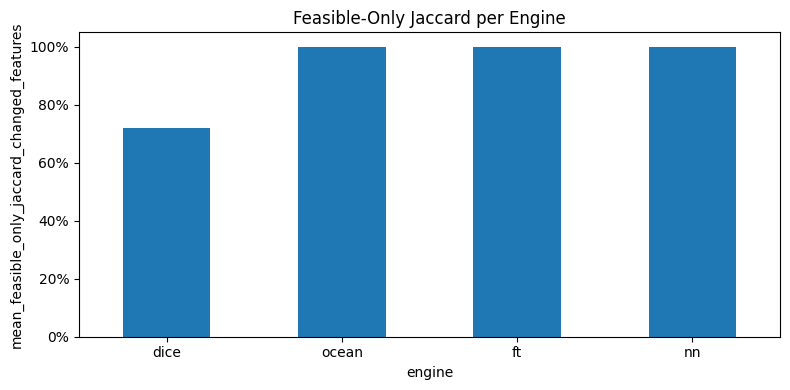

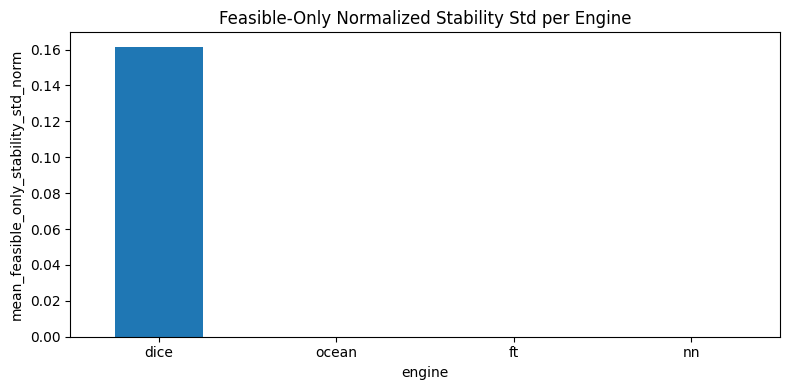

In [8]:
if not stability_df.empty:
    stability_view = stability_df.copy()
    stability_view["engine"] = pd.Categorical(
        stability_view["source_file"].map(extract_engine_from_source),
        categories=ENGINE_ORDER,
        ordered=True,
    )
    stability_view = stability_view[[
        "engine",
        "mean_feasible_rate",
        "fully_feasible_case_rate",
        "mean_feasible_only_jaccard_changed_features",
        "mean_feasible_only_stability_std_norm",
    ]].sort_values("engine").reset_index(drop=True)

    display(
        style_metric_table(
            stability_view,
            percent_cols=[
                "mean_feasible_rate",
                "fully_feasible_case_rate",
                "mean_feasible_only_jaccard_changed_features",
            ],
            hide_index=True,
        )
    )

    stability_metrics_percent = [
        ("mean_feasible_rate", "Mean Feasible Rate per Engine"),
        ("fully_feasible_case_rate", "Fully Feasible Case Rate per Engine"),
        ("mean_feasible_only_jaccard_changed_features", "Feasible-Only Jaccard per Engine"),
    ]
    for metric, title in stability_metrics_percent:
        metric_plot = stability_view.set_index("engine")[[metric]].reindex(ENGINE_ORDER)
        ax = metric_plot.plot(
            kind="bar",
            figsize=(8, 4),
            rot=0,
            legend=False,
            color=[ENGINE_COLORS.get(engine, "#4b5563") for engine in metric_plot.index],
        )
        ax.set_title(title)
        ax.set_xlabel("engine")
        ax.set_ylabel(metric)
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        plt.tight_layout()
        plt.show()

    std_plot = stability_view.set_index("engine")[["mean_feasible_only_stability_std_norm"]].reindex(ENGINE_ORDER)
    ax = std_plot.plot(
        kind="bar",
        figsize=(8, 4),
        rot=0,
        legend=False,
        color=[ENGINE_COLORS.get(engine, "#4b5563") for engine in std_plot.index],
    )
    ax.set_title("Feasible-Only Normalized Stability Std per Engine")
    ax.set_xlabel("engine")
    ax.set_ylabel("mean_feasible_only_stability_std_norm")
    plt.tight_layout()
    plt.show()

    best_stability = stability_view.sort_values(
        ["fully_feasible_case_rate", "mean_feasible_only_jaccard_changed_features", "mean_feasible_only_stability_std_norm"],
        ascending=[False, False, True],
    ).iloc[0]
    stability_note = (
        f"**Takeaway stabilitas.** Engine yang paling kuat pada stabilitas saat ini adalah **{best_stability['engine']}**, "
        f"dengan `fully_feasible_case_rate` {best_stability['fully_feasible_case_rate']:.1%}, "
        f"`Jaccard` {best_stability['mean_feasible_only_jaccard_changed_features']:.1%}, dan "
        f"`std_norm` {best_stability['mean_feasible_only_stability_std_norm']:.3f}."
    )


## 7. Matriks Keputusan dan Efisiensi

Bagian akhir ini menyatukan outcome operasional, stabilitas, plausibility, dan runtime ke dalam satu matriks keputusan. Stress test dan kontrol infeasible tetap dibaca sebagai bukti robustness dan correct rejection, tetapi tidak dicampur ke outcome operasional utama.

Matriks ini bukan skor total arbitrer. Tujuannya adalah memberi ringkasan pembanding yang transparan: siapa unggul pada coverage operasional, siapa unggul pada stabilitas, dan siapa yang paling efisien secara runtime.

engine,feasible_rate,plausibility_pass_rate,mean_lof_score,mean_runtime_ms,mean_feasible_rate,fully_feasible_case_rate,mean_feasible_only_jaccard_changed_features,mean_feasible_only_stability_std_norm
dice,85.0%,100.0%,1.185,539.550,100.0%,100.0%,72.1%,0.162
ocean,40.0%,100.0%,1.011,3122.250,66.0%,60.0%,100.0%,0.000
ft,37.5%,75.0%,0.757,195.338,40.0%,40.0%,100.0%,0.000
nn,81.2%,100.0%,1.019,369.525,100.0%,100.0%,100.0%,0.000


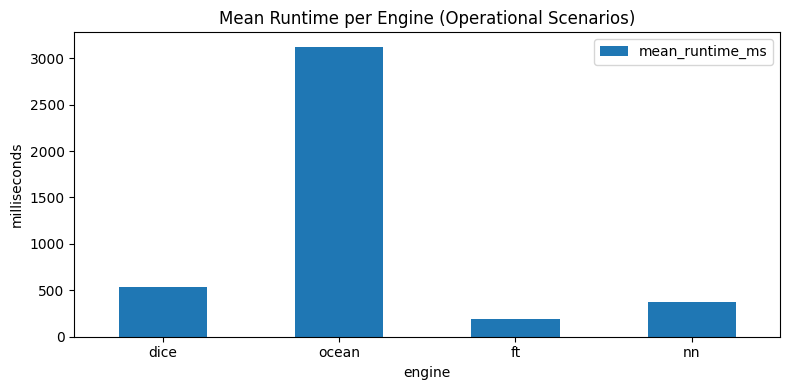

In [9]:
scenario_engine_summary = pd.DataFrame()
if not scenario_df.empty:
    scenario_engine_summary = (
        scenario_df.assign(
            engine=scenario_df["source_file"].map(extract_engine_from_source),
            scenario_group=scenario_df["scenario"].map(classify_scenario),
        )
        .loc[lambda df: df["scenario_group"] == "operational"]
        .groupby("engine", as_index=False)
        .agg(
            feasible_rate=("feasible_rate", "mean"),
            plausibility_pass_rate=("plausibility_pass_rate", "mean"),
            mean_lof_score=("mean_lof_score", "mean"),
            mean_runtime_ms=("mean_runtime_ms", "mean"),
        )
    )

stability_engine_summary = pd.DataFrame()
if not stability_df.empty:
    stability_engine_summary = (
        stability_df.assign(engine=stability_df["source_file"].map(extract_engine_from_source))[[
            "engine",
            "mean_feasible_rate",
            "fully_feasible_case_rate",
            "mean_feasible_only_jaccard_changed_features",
            "mean_feasible_only_stability_std_norm",
        ]].copy()
    )

if not scenario_engine_summary.empty:
    decision_matrix = scenario_engine_summary.merge(stability_engine_summary, on="engine", how="left")
    decision_matrix["engine"] = pd.Categorical(decision_matrix["engine"], categories=ENGINE_ORDER, ordered=True)
    decision_matrix = decision_matrix.sort_values("engine").reset_index(drop=True)

    display(
        style_metric_table(
            decision_matrix,
            percent_cols=[
                "feasible_rate",
                "plausibility_pass_rate",
                "mean_feasible_rate",
                "fully_feasible_case_rate",
                "mean_feasible_only_jaccard_changed_features",
            ],
            hide_index=True,
        )
    )

    runtime_view = decision_matrix.set_index("engine")[["mean_runtime_ms"]]
    ax = runtime_view.plot(kind="bar", figsize=(8, 4), rot=0, color=[ENGINE_COLORS.get(engine, "#4b5563") for engine in runtime_view.index])
    ax.set_title("Mean Runtime per Engine (Operational Scenarios)")
    ax.set_ylabel("milliseconds")
    plt.tight_layout()
    plt.show()

    top_operational = decision_matrix.sort_values("feasible_rate", ascending=False).iloc[0]
    top_runtime = decision_matrix.sort_values("mean_runtime_ms", ascending=True).iloc[0]
    top_stability = decision_matrix.sort_values(
        ["fully_feasible_case_rate", "mean_feasible_only_jaccard_changed_features", "mean_feasible_only_stability_std_norm"],
        ascending=[False, False, True],
    ).iloc[0]
    